In [84]:
import pandas as pd

# Đọc CSV chứa nhãn (groundtruth)
gt_path = 'data/raw/ISIC_2019_Training_GroundTruth.csv'
df_gt = pd.read_csv(gt_path)

# Đọc metadata (có cột lesion_id)
meta_path = 'data/raw/ISIC_2019_Training_Metadata.csv'
df_meta = pd.read_csv(meta_path)

# Lấy chỉ những cột cần thiết từ metadata
df_meta_small = df_meta[['image', 'lesion_id']]

# Merge theo cột 'image' để thu được data cuối cùng cho split
df = pd.merge(df_gt, df_meta_small, on='image')


In [85]:
df

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK,lesion_id
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
25326,ISIC_0073247,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,BCN_0003925
25327,ISIC_0073248,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,BCN_0001819
25328,ISIC_0073249,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BCN_0001085
25329,ISIC_0073251,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BCN_0002083


In [86]:
df.drop('UNK', axis=1, inplace=True)

In [87]:
import os
DATA_DIR = 'data/processed/cropped_lesions/'

In [88]:
classes = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

# Chuyển từ One-Hot Encoding sang Single Label
df['label'] = df[classes].idxmax(axis=1)
df['path'] = df['image'].apply(lambda x: os.path.join(DATA_DIR, x + '.jpg'))

print("\nDữ liệu sau khi xử lý:")
display(df[['image', 'label', 'path']].head())

print(f"Tổng số lượng mẫu: {len(df)}")


Dữ liệu sau khi xử lý:


,image,label,path
0,ISIC_0000000,NV,data/processed/cropped_lesions/ISIC_0000000.jpg
1,ISIC_0000001,NV,data/processed/cropped_lesions/ISIC_0000001.jpg
2,ISIC_0000002,MEL,data/processed/cropped_lesions/ISIC_0000002.jpg
3,ISIC_0000003,NV,data/processed/cropped_lesions/ISIC_0000003.jpg
4,ISIC_0000004,MEL,data/processed/cropped_lesions/ISIC_0000004.jpg


Tổng số lượng mẫu: 25331


In [89]:
df.drop(['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC'], axis=1, inplace=True)

In [90]:
df

,image,lesion_id,label,path
0,ISIC_0000000,NaN,NV,data/processed/cropped_lesions/ISIC_0000000.jpg
1,ISIC_0000001,NaN,NV,data/processed/cropped_lesions/ISIC_0000001.jpg
2,ISIC_0000002,NaN,MEL,data/processed/cropped_lesions/ISIC_0000002.jpg
3,ISIC_0000003,NaN,NV,data/processed/cropped_lesions/ISIC_0000003.jpg
4,ISIC_0000004,NaN,MEL,data/processed/cropped_lesions/ISIC_0000004.jpg
...,...,...,...,...
25326,ISIC_0073247,BCN_0003925,BCC,data/processed/cropped_lesions/ISIC_0073247.jpg
25327,ISIC_0073248,BCN_0001819,BKL,data/processed/cropped_lesions/ISIC_0073248.jpg
25328,ISIC_0073249,BCN_0001085,MEL,data/processed/cropped_lesions/ISIC_0073249.jpg
25329,ISIC_0073251,BCN_0002083,NV,data/processed/cropped_lesions/ISIC_0073251.jpg


In [92]:
df.to_csv("ISIC_2019_final_metadata.csv", index=False)

In [95]:
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

# 1. Đọc file metadata
csv_path = "ISIC_2019_final_metadata.csv"
df = pd.read_csv(csv_path)

print(f"Tổng số mẫu ban đầu: {len(df)}")
print(f"Số lượng lesion_id bị thiếu: {df['lesion_id'].isnull().sum()}")

# 2. Xử lý lesion_id bị thiếu
# Rất quan trọng: Với những ảnh không có lesion_id (NaN), ta giả định nó là một vết bệnh duy nhất.
# Ta sẽ điền chính image_id vào chỗ thiếu đó để nó thành một group riêng biệt.
df['lesion_id'] = df['lesion_id'].fillna(df['image'])

# 3. Khởi tạo StratifiedGroupKFold
# shuffle=True để xáo trộn dữ liệu trước khi chia (tốt cho training)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Tạo cột 'fold' mặc định là -1
df['fold'] = -1

# 4. Thực hiện chia Fold
# X: Dữ liệu (chỉ cần index hoặc tên ảnh)
# y: Nhãn cần cân bằng (cột 'label')
# groups: Nhóm cần giữ nguyên (cột 'lesion_id')
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X=df, y=df['label'], groups=df['lesion_id'])):
    df.loc[val_idx, 'fold'] = fold

# 5. Kiểm tra kết quả phân bố
print("\n--- Phân bố dữ liệu sau khi chia Fold ---")
print(df.groupby('fold')['label'].value_counts())

# Kiểm tra xem các fold có kích thước tương đương không
print("\nKích thước các Fold:")
print(df['fold'].value_counts())

# 6. Lưu file mới
output_path = "ISIC_2019_5folds_metadata.csv"
df.to_csv(output_path, index=False)
print(f"\n✅ Đã lưu file metadata đã chia fold tại: {output_path}")

Tổng số mẫu ban đầu: 25331
Số lượng lesion_id bị thiếu: 2084

--- Phân bố dữ liệu sau khi chia Fold ---
fold  label
0     NV       2591
      MEL       827
      BCC       732
      BKL       509
      AK        142
      SCC       102
      VASC       67
      DF         53
1     NV       2483
      MEL       997
      BCC       637
      BKL       531
      AK        182
      SCC       158
      DF         42
      VASC       30
2     NV       2580
      MEL       996
      BCC       696
      BKL       483
      AK        155
      SCC       109
      VASC       70
      DF         44
3     NV       2641
      MEL       806
      BCC       686
      BKL       542
      AK        207
      SCC       118
      DF         40
      VASC       39
4     NV       2580
      MEL       896
      BCC       572
      BKL       559
      AK        181
      SCC       141
      DF         60
      VASC       47
Name: count, dtype: int64

Kích thước các Fold:
fold
2    5133
3    5079
1    5060
4

Số lượng mẫu từng lớp trong mỗi Fold:


label,AK,BCC,BKL,DF,MEL,NV,SCC,VASC
fold,,,,,,,,
0,142,732,509,53,827,2591,102,67
1,182,637,531,42,997,2483,158,30
2,155,696,483,44,996,2580,109,70
3,207,686,542,40,806,2641,118,39
4,181,572,559,60,896,2580,141,47



Tỉ lệ phần trăm từng lớp trong mỗi Fold:


label,AK,BCC,BKL,DF,MEL,NV,SCC,VASC
fold,,,,,,,,
0,2.83,14.57,10.13,1.06,16.46,51.58,2.03,1.33
1,3.60,12.59,10.49,0.83,19.70,49.07,3.12,0.59
2,3.02,13.56,9.41,0.86,19.40,50.26,2.12,1.36
3,4.08,13.51,10.67,0.79,15.87,52.00,2.32,0.77
4,3.59,11.36,11.10,1.19,17.79,51.23,2.80,0.93


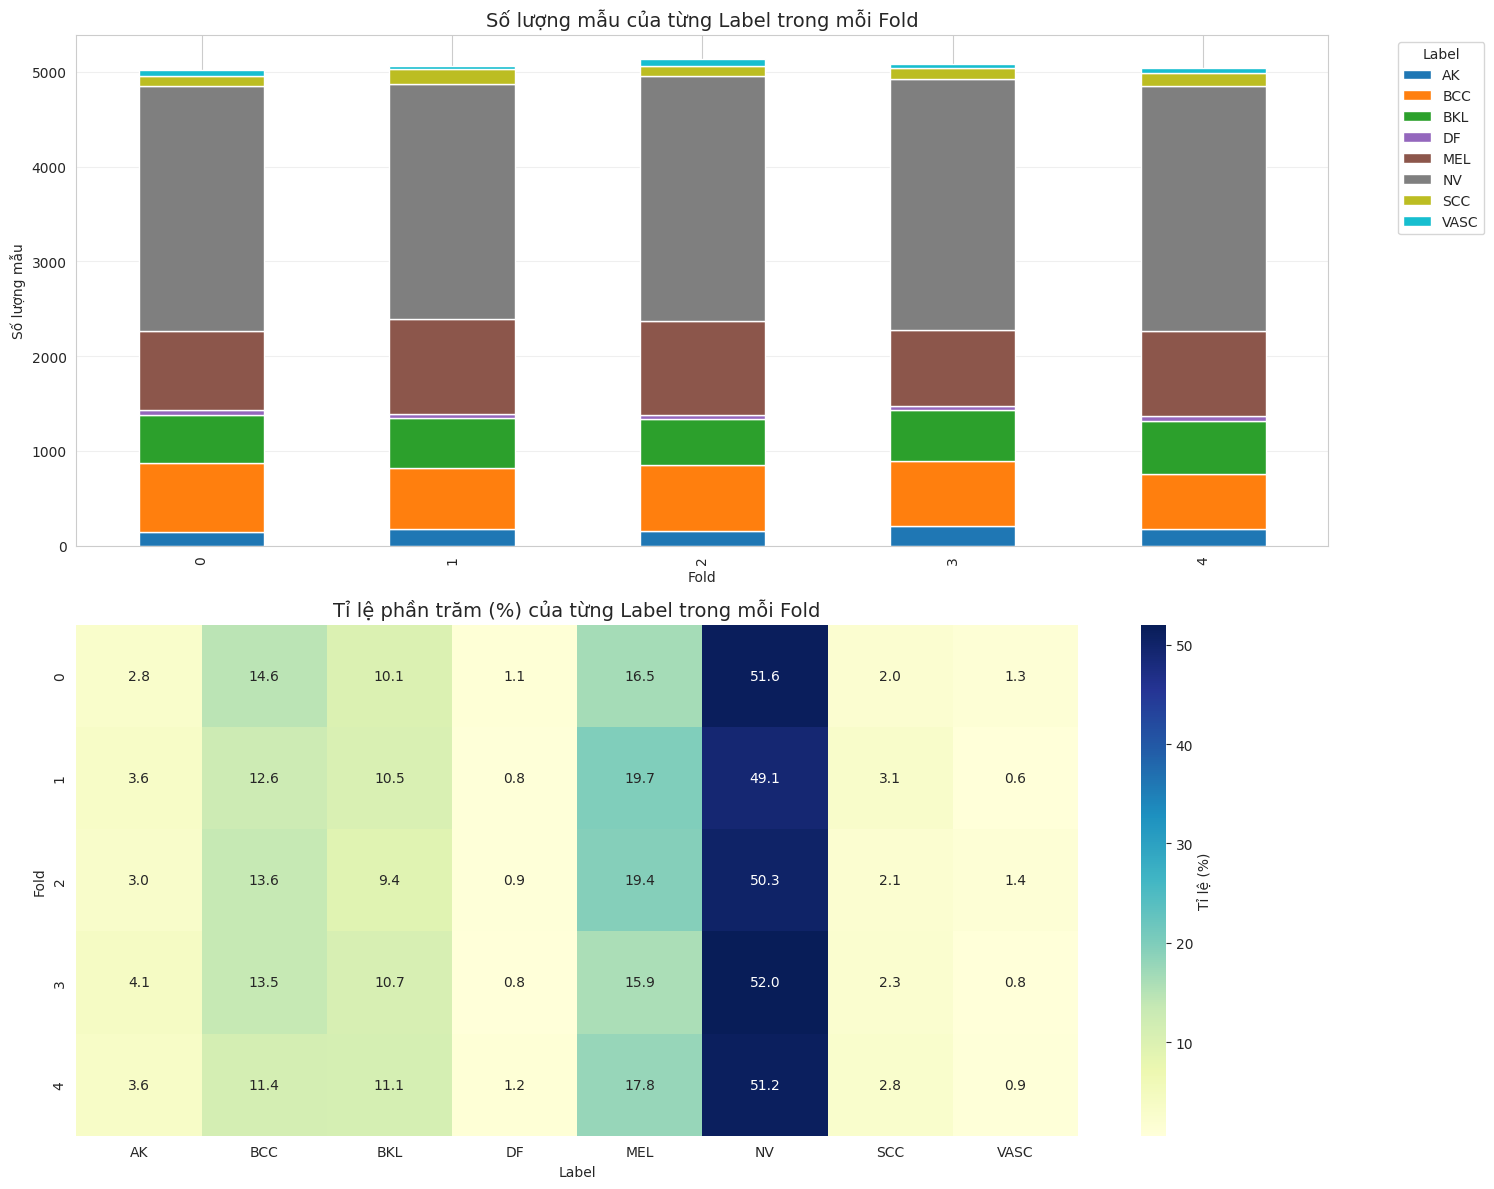


Độ lệch chuẩn của tỉ lệ phần trăm các lớp giữa các fold (càng nhỏ càng tốt):
label
DF      0.172168
VASC    0.341989
SCC     0.466018
AK      0.500821
BKL     0.635819
NV      1.173431
BCC     1.208245
MEL     1.710047
dtype: float64


In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc file metadata đã chia fold
df_folds = pd.read_csv('ISIC_2019_5folds_metadata.csv')

# 2. Tính toán thống kê
# Tạo bảng chéo (crosstab) giữa Fold và Label
fold_label_counts = pd.crosstab(df_folds['fold'], df_folds['label'])
fold_label_percentages = pd.crosstab(df_folds['fold'], df_folds['label'], normalize='index') * 100

print("Số lượng mẫu từng lớp trong mỗi Fold:")
display(fold_label_counts)

print("\nTỉ lệ phần trăm từng lớp trong mỗi Fold:")
display(fold_label_percentages.round(2))

# 3. Trực quan hóa
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Biểu đồ 1: Stacked Bar Chart (Số lượng tuyệt đối)
fold_label_counts.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10')
axes[0].set_title('Số lượng mẫu của từng Label trong mỗi Fold', fontsize=14)
axes[0].set_ylabel('Số lượng mẫu')
axes[0].set_xlabel('Fold')
axes[0].legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(axis='y', alpha=0.3)

# Biểu đồ 2: Heatmap (Tỉ lệ phần trăm)
sns.heatmap(fold_label_percentages, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1], cbar_kws={'label': 'Tỉ lệ (%)'})
axes[1].set_title('Tỉ lệ phần trăm (%) của từng Label trong mỗi Fold', fontsize=14)
axes[1].set_ylabel('Fold')
axes[1].set_xlabel('Label')

plt.tight_layout()
plt.show()

# Kiểm tra độ lệch chuẩn của tỉ lệ các lớp giữa các fold (để xem chia đều không)
std_dev = fold_label_percentages.std()
print("\nĐộ lệch chuẩn của tỉ lệ phần trăm các lớp giữa các fold (càng nhỏ càng tốt):")
print(std_dev.sort_values())

In [98]:
# Định nghĩa danh sách các class theo thứ tự mong muốn (như đã định nghĩa ở trên)
classes = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

# Tạo mapping từ text sang số
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
print("Mapping từ nhãn text sang số:")
for cls, idx in class_to_idx.items():
    print(f"  {cls} -> {idx}")

# Đọc file metadata
df = pd.read_csv('ISIC_2019_5folds_metadata.csv')

# Tạo cột 'target' bằng cách map cột 'label'
df['target'] = df['label'].map(class_to_idx)

# Kiểm tra xem có nhãn nào không map được không
if df['target'].isnull().any():
    print("\n⚠️ Cảnh báo: Có nhãn không nằm trong danh sách classes!")
    print("Các nhãn lạ:", df[df['target'].isnull()]['label'].unique())
else:
    print("\n✅ Chuyển đổi thành công tất cả các nhãn.")

# Hiển thị dữ liệu sau khi thêm cột target
print("\nDữ liệu sau khi xử lý:")
display(df.head())

# Lưu lại file CSV
df.to_csv('ISIC_2019_5folds_metadata.csv', index=False)
print("\n✅ Đã lưu file cập nhật: ISIC_2019_5folds_metadata.csv")

Mapping từ nhãn text sang số:
  MEL -> 0
  NV -> 1
  BCC -> 2
  AK -> 3
  BKL -> 4
  DF -> 5
  VASC -> 6
  SCC -> 7

✅ Chuyển đổi thành công tất cả các nhãn.

Dữ liệu sau khi xử lý:


,image,lesion_id,label,path,fold,target
0,ISIC_0000000,ISIC_0000000,NV,data/processed/cropped_lesions/ISIC_0000000.jpg,2,1
1,ISIC_0000001,ISIC_0000001,NV,data/processed/cropped_lesions/ISIC_0000001.jpg,0,1
2,ISIC_0000002,ISIC_0000002,MEL,data/processed/cropped_lesions/ISIC_0000002.jpg,2,0
3,ISIC_0000003,ISIC_0000003,NV,data/processed/cropped_lesions/ISIC_0000003.jpg,1,1
4,ISIC_0000004,ISIC_0000004,MEL,data/processed/cropped_lesions/ISIC_0000004.jpg,2,0



✅ Đã lưu file cập nhật: ISIC_2019_5folds_metadata.csv
